In [2]:
import re
import os
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import math
import pandas as pd
from io import StringIO
from scipy.interpolate import CubicSpline, interp1d
params = {
          'font.size' : 11,
          }
        #   'font.family' : 'qhv',
plt.rcParams.update(params)

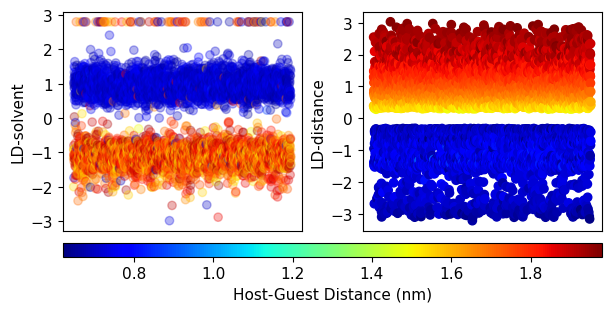

In [62]:
#Load npy files
def load_npy_files(directory):
    files = os.listdir(directory)
    files = [file for file in files if file.endswith('.npy')]
    files.sort()
    data = {}
    for file in files:
        data[file.split('.')[0]] = (np.load(os.path.join(directory,file)))
    return data

directory_solvec = './ce_training_3'
epach_stem_solvec = 'VAE_2000'
data_solvec = load_npy_files(directory_solvec)
labels_solvec = data_solvec[epach_stem_solvec +'_labels'][:,0]

directory_distvec = './distvec_2'
epach_stem_distvec = 'VAE_500'
data_distvec = load_npy_files(directory_distvec)
labels_distvec = data_distvec[epach_stem_distvec +'_labels'][:,0]


fig, ax = plt.subplots(1, 2, figsize=(6, 3), layout='constrained')

cm = plt.get_cmap('jet')
cNorm_distvec = matplotlib.colors.Normalize(vmin=min(labels_distvec), vmax=max(labels_distvec))
scalarMap_distvec = matplotlib.cm.ScalarMappable(norm=cNorm_distvec, cmap=cm)

x_distvec = data_distvec[epach_stem_distvec +'_latent_mu'][:,0].shape[0]
ax[1].scatter(range(x_distvec), data_distvec[epach_stem_distvec +'_latent_mu'][:,0], c=scalarMap_distvec.to_rgba(labels_distvec))


cNorm_solvec = matplotlib.colors.Normalize(vmin=min(labels_solvec), vmax=max(labels_solvec))
scalarMap_solvec = matplotlib.cm.ScalarMappable(norm=cNorm_solvec, cmap=cm)

x_solvec = data_solvec[epach_stem_solvec +'_latent_mu'][:,0].shape[0]
ax[0].scatter(range(x_solvec), data_solvec[epach_stem_solvec +'_latent_mu'][:,0], c=scalarMap_solvec.to_rgba(labels_solvec), alpha=0.3)
# ax.plot(labels_distvec, data_distvec[epach_stem_distvec +'_latent_mu'][:,0], 'o', markersize=2)

ax[0].set_ylabel('LD-solvent')
ax[0].set_xticks([])

ax[1].set_ylabel('LD-distance')
ax[1].set_xticks([])

scalarMap_distvec.set_array(labels_distvec)
cb = fig.colorbar(scalarMap_distvec, ax=ax, location='bottom', aspect=40)
cb.set_label("Host-Guest Distance (nm)")

plt.savefig('initial_classification.pdf', dpi=300, bbox_inches='tight')
plt.show()


